# Loan Approval Prediction System
  *An AI-Powered Loan Approval System*

------------------------------------

#1. Problem Statement

This project addresses one of the most critical challenges in the **banking** and **financial** sector evaluating loan applications efficiently and accurately.

Traditional manual processes are slow, inconsistent, and prone to human bias.

This project builds an automated ML pipeline to predict whether a loan should be approved or rejected based on applicant data.

# Objective

The goal is to train a binary classification model using features such as:

* Annual Income
* Credit Score
* Total Assets
* Loan Amount
* Employment Information



The model supports faster, fairer, and data-driven lending decisions.

# Business Impact

* Identify low-risk applicants for approval
* Flag high-risk applicants
* Reduce manual review time
* Minimize human error
* Ensure consistent decision criteria

# Algorithms Used

* Logistic Regression - baseline linear model
* Decision Tree - captures non-linear patterns
* Random Forest - reduces variance using ensemble learning

# DataSet
* Source: Kaggle
* Columns: 13
* Target Column/Variable: Loan Status (Loan Approved/ Loan Rejected)

The dataset contains 4,269 loan applications with 13 features covering demographic and financial information.

# Project Workflow

1. Problem Understanding

2. Data Collection

3. Data Cleaning

4. Exploratory Data Analysis

5. Feature Engineering

6. Model Training

7. Model Evaluation

8. Model Deployment

# Importing Libraries

In [1]:
# For Data Analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For ML
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score

# For Warnings

import warnings
warnings.filterwarnings('ignore')

# Loading & Reading Dataset

In [2]:
df = pd.read_csv('data/loan_approval_dataset.csv')
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


# Exploratory Data Analysis (EDA)

In [3]:
# Dataset shape
print(f"Dataset shape: {df.shape}")

Dataset shape: (4269, 13)


In [4]:
# Exploring columns
print(f"Dataset Columns: {df.columns}")

Dataset Columns: Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')


In [5]:
print("=" * 55)
print(f"{" " * 19} Dataset Information")
print("=" * 55)
df.info()



                    Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)

In [6]:
print("=" * 115)
print(f"{" " * 45} Data Description")
print("=" * 115)
df.describe().T

                                              Data Description


,count,mean,std,min,25%,50%,75%,max
loan_id,4269.0,2.135000e+03,1.232498e+03,1.0,1068.0,2135.0,3202.0,4269.0
no_of_dependents,4269.0,2.498712e+00,1.695910e+00,0.0,1.0,3.0,4.0,5.0
income_annum,4269.0,5.059124e+06,2.806840e+06,200000.0,2700000.0,5100000.0,7500000.0,9900000.0
loan_amount,4269.0,1.513345e+07,9.043363e+06,300000.0,7700000.0,14500000.0,21500000.0,39500000.0
loan_term,4269.0,1.090045e+01,5.709187e+00,2.0,6.0,10.0,16.0,20.0
cibil_score,4269.0,5.999361e+02,1.724304e+02,300.0,453.0,600.0,748.0,900.0
residential_assets_value,4269.0,7.472617e+06,6.503637e+06,-100000.0,2200000.0,5600000.0,11300000.0,29100000.0
commercial_assets_value,4269.0,4.973155e+06,4.388966e+06,0.0,1300000.0,3700000.0,7600000.0,19400000.0
luxury_assets_value,4269.0,1.512631e+07,9.103754e+06,300000.0,7500000.0,14600000.0,21700000.0,39200000.0
bank_asset_value,4269.0,4.976692e+06,3.250185e+06,0.0,2300000.0,4600000.0,7100000.0,14700000.0


In [7]:
# Dropping irrevelent columns
df.drop(columns=['loan_id'], axis= 1, inplace = True)

print("loan_id dropped successfully...")
print(f"New Data shape: {df.shape}")

loan_id dropped successfully...
New Data shape: (4269, 12)


In [8]:
# Finding missing values
df.isnull().sum()

,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0
luxury_assets_value,0


In [9]:
# finding duplicate values
print(f"Duplicate values: {df.duplicated().sum()}")

Duplicate values: 0


In [10]:
# Handling negative asset_values

negative_assets = df[df[' residential_assets_value']< 0]
print(f"Rows with negative residential_asset values: {negative_assets.shape[0]}")

df = df[df[" residential_assets_value"] >= 0]
print(f"New Data shape after removing negative values: {df.shape}")


Rows with negative residential_asset values: 28
New Data shape after removing negative values: (4241, 12)


**Initial Observations**



*   Dataset shape includes 4269 loan applications.

*   It has 13 columns.

*   There are 10 int64 and 03 Object data types(dtypes).

*   There is no any null value found to be cleaned or filled.

*   An irrelevant column named 'loan_id' found which was removed later.

*   There is no dupplicated value found in the dataframe.

*   In the initial stage, 28 negative residential_asset_values found.

*   After removing 28 negative entries, the new datashape contains 4241 entries, and 12 columns.






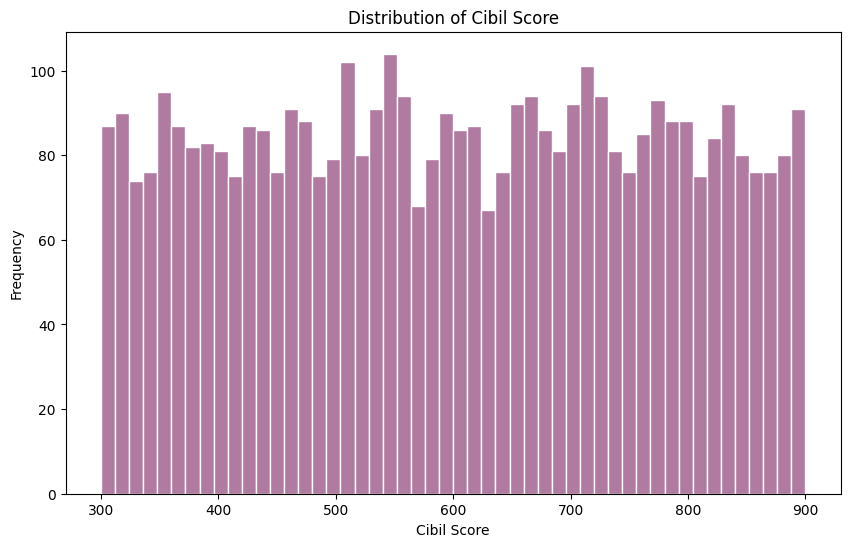

In [11]:
import matplotlib.pyplot as plt

# Distribution for Cibil_score
plt.figure(figsize=(10, 6))
plt.hist(df[' cibil_score'], bins=50, color='#B07AA1', edgecolor='white')
plt.xlabel('Cibil Score')
plt.ylabel('Frequency')
plt.title('Distribution of Cibil Score')
plt.grid(True, linestyle='--', alpha =0)
plt.show()

**Observations**

* The Cibil scores are spread across the whole range from **300 to 900**.
* Most score ranges have a **similar number of people**, so no single score range stands out.
* There are **no very high or very low peaks**, which means the scores are fairly evenly distributed.
* A few score ranges have **slightly more people than others**, but the difference is small.
* Overall, the histogram shows that **Cibil scores are balanced across the range** without any clear pattern.


# Target Variable Distribution

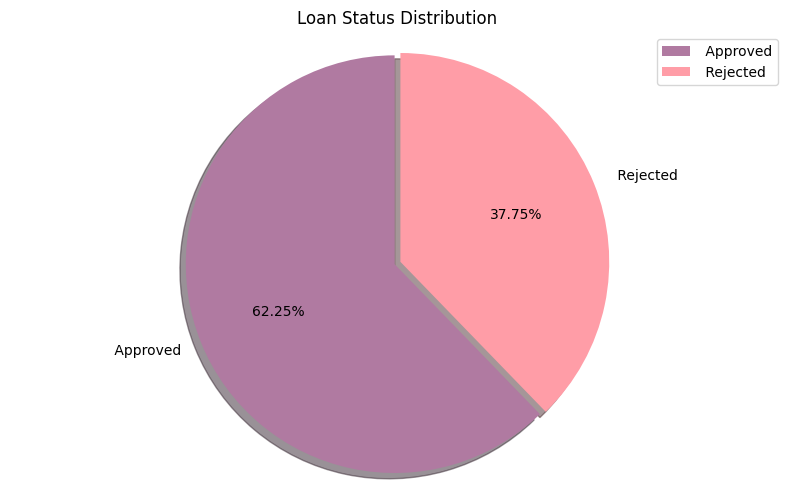

In [12]:
colors_used = ['#B07AA1', '#FF9DA7']
plt.figure(figsize=(10, 6))
explode = (0, 0.03)
plt.pie(df[' loan_status'].value_counts().values,
        labels = df[' loan_status'].value_counts().index,
        colors = colors_used[:len (df[' loan_status'].value_counts()) ],
        explode = explode,
        autopct = '%1.2f%%',
        shadow = True,
        startangle = 90
        )
plt.title('Loan Status Distribution')
plt.axis('equal')
plt.legend()
plt.show()

**Observations**

* The chart shows that **62.25%** of the applications were **Approved**, which is the larger share.
* **Rejected** loan applications make up **37.75%** of the total, which is much lower than approved items.
* There are **more approved cases than rejected cases**, showing that approvals are more common.
* About **6 out of every 10** applications were approved, while **around 4 out of every 10** were rejected.
* The difference between approved and rejected cases is **24.5 percentage points**, showing a clear lead for approvals.




# Numerical Columns Distribution

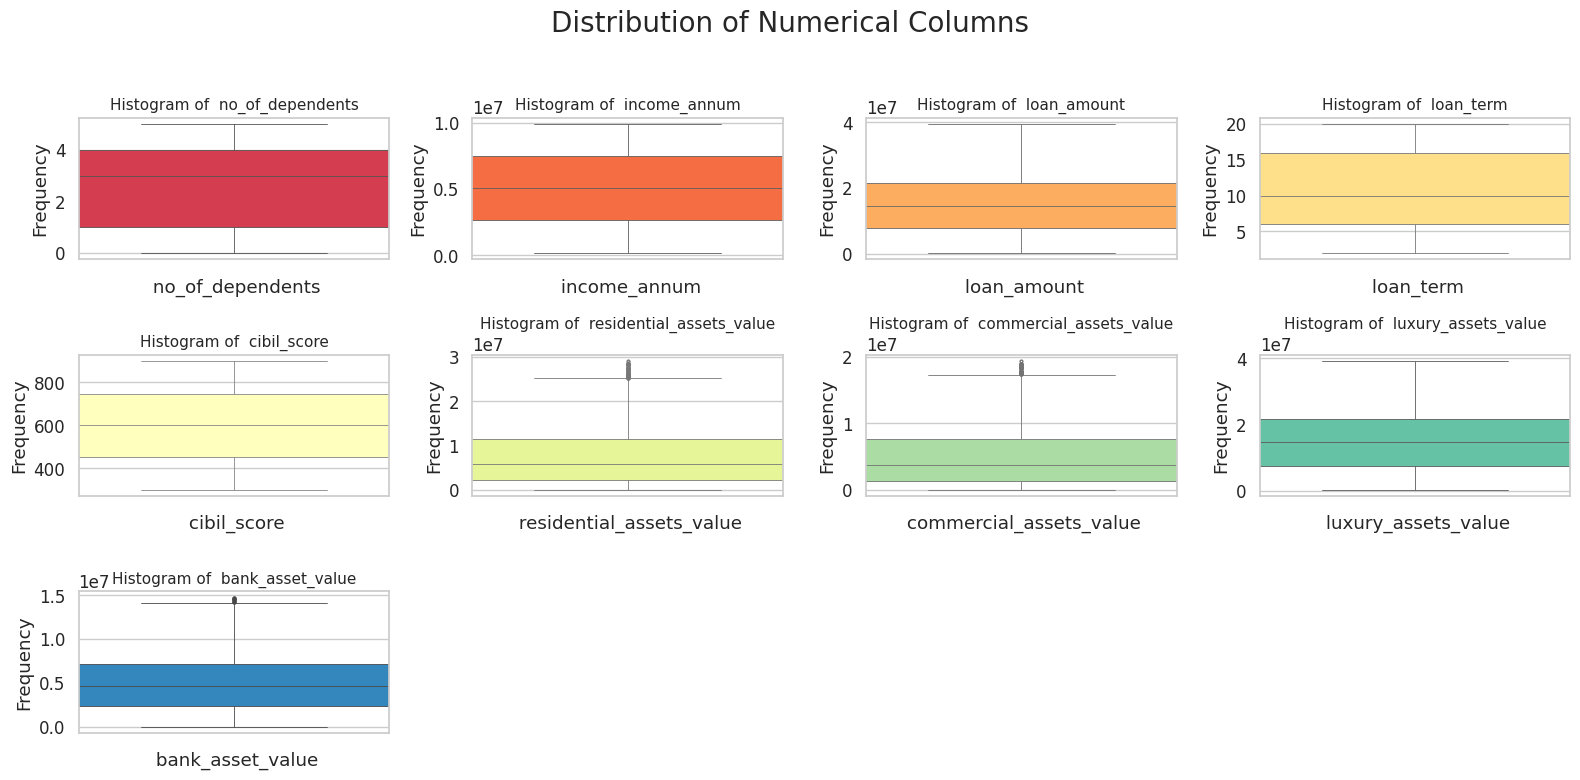

In [13]:
from numpy._core import numeric
# Distribution of Numerical columns
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

# setting seaborn theme
sns.set_theme(style="whitegrid", palette ="Spectral", font_scale= 1.1)

# Defining color palettes
palette = sns.color_palette("Spectral", n_colors=len(numeric_columns))

# Create a figure with multiple subplots
plt.figure(figsize=(16, 10))

for i, col in enumerate(numeric_columns, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(df[col],
                color=palette[i-1],
                linewidth=0.6,
                saturation=1,
                fliersize=2,
                width= 1.2
                )
    plt.title(f'Histogram of {col}', fontsize = 11)
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()


plt.suptitle('Distribution of Numerical Columns', fontsize = 20)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()




**Observations**

* Most numerical columns show a **wide spread of values**, which means the data is not concentrated in a small range.
* The **asset-related columns** (residential, commercial, luxury, and bank asset values) have a few **high-value outliers**, showing that some records have much larger values than the rest.
* The **loan amount** and **income per year** also vary a lot, indicating that applicants have different income levels and loan requirements.
* The **loan term**, **number of dependents**, and **CIBIL score** appear to have a more balanced distribution compared to the asset value columns.
* Overall, the dataset contains **different ranges of numerical values**, making it suitable for further analysis after handling the outliers.


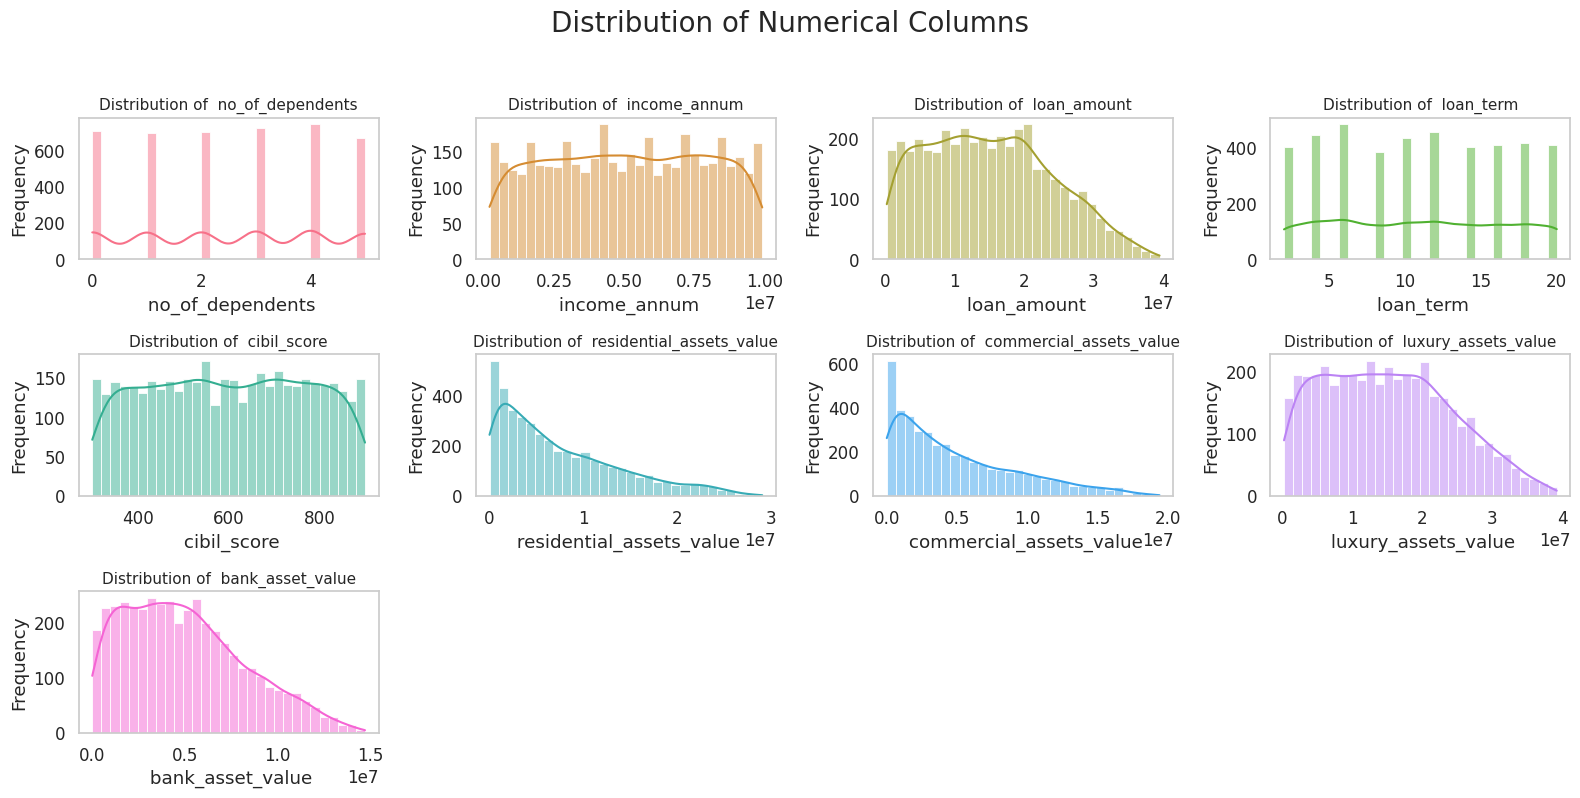

In [14]:
# Distribution of all Numerical columns via Histplots
palette = sns.color_palette("husl", len(numeric_columns))

plt.figure(figsize=(16, 10))

for i, col in enumerate(numeric_columns, 1):
    plt.subplot(4, 4, i)
    sns.histplot(df[col],
                 color=palette[i-1],
                 kde=True,
                 bins=30
                 )
    plt.title(f'Distribution of {col}',
              fontsize = 11)
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(True, linestyle='--', alpha =0)


plt.suptitle('Distribution of Numerical Columns', fontsize = 20)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()





# Observations of Numerical Column Distributions

* Most **asset-related variables** (residential, commercial, luxury, bank assets, and loan amount) are **right-skewed**, meaning most applicants have lower values while only a few have very high values.
* **Annual income**, **CIBIL score**, **loan term**, and **number of dependents** appear to be **fairly balanced**, with values spread evenly across their ranges.
* No major gaps or abnormal patterns are visible in the distributions.
* Several financial features have **long right tails**, suggesting the presence of a few high-value applicants.
* The dataset contains a good mix of low, medium, and high-value observations, making it suitable for predictive modeling.
* Right-skewed variables may benefit from transformations (such as **log transformation**) before applying certain machine learning algorithms.
* Since the numerical features are measured on very different scales (for example, CIBIL score vs. asset values), **feature scaling or normalization** may improve model performance.
* Overall, the numerical data looks clean, well distributed, and suitable for exploratory data analysis and machine learning after standard preprocessing steps.


# Categorical Features Distribution and Target Analysis

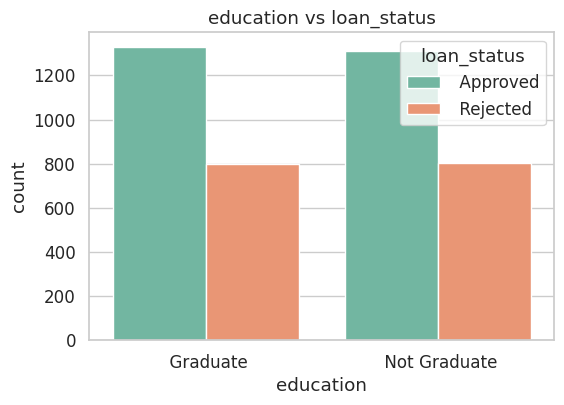

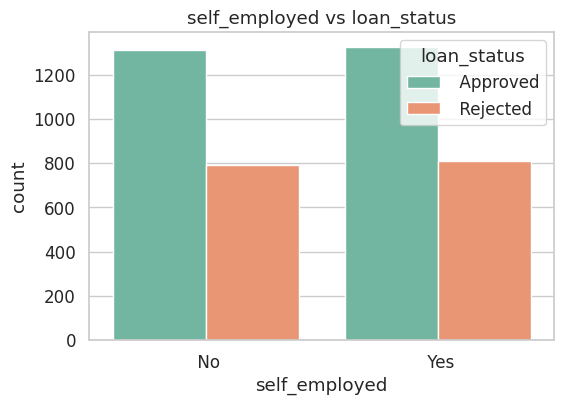

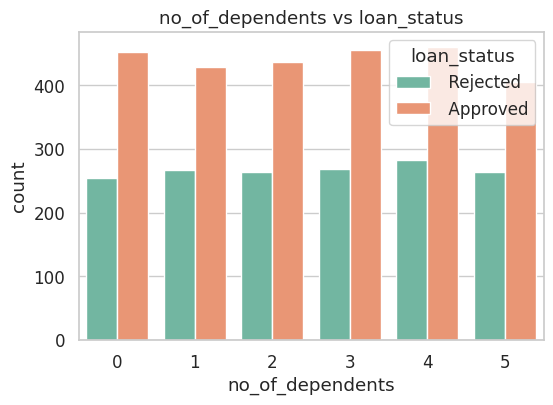

In [15]:
df.columns = df.columns.str.strip()

target = "loan_status"

# Categorical Columns

categorical = ["education", "self_employed", "no_of_dependents"]

for col in categorical:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col,
                  hue=target,
                  data=df,
                  palette="Set2")
    plt.title(f"{col} vs {target}")
    plt.show()

# Numerical Features Distribution & Target Analysis


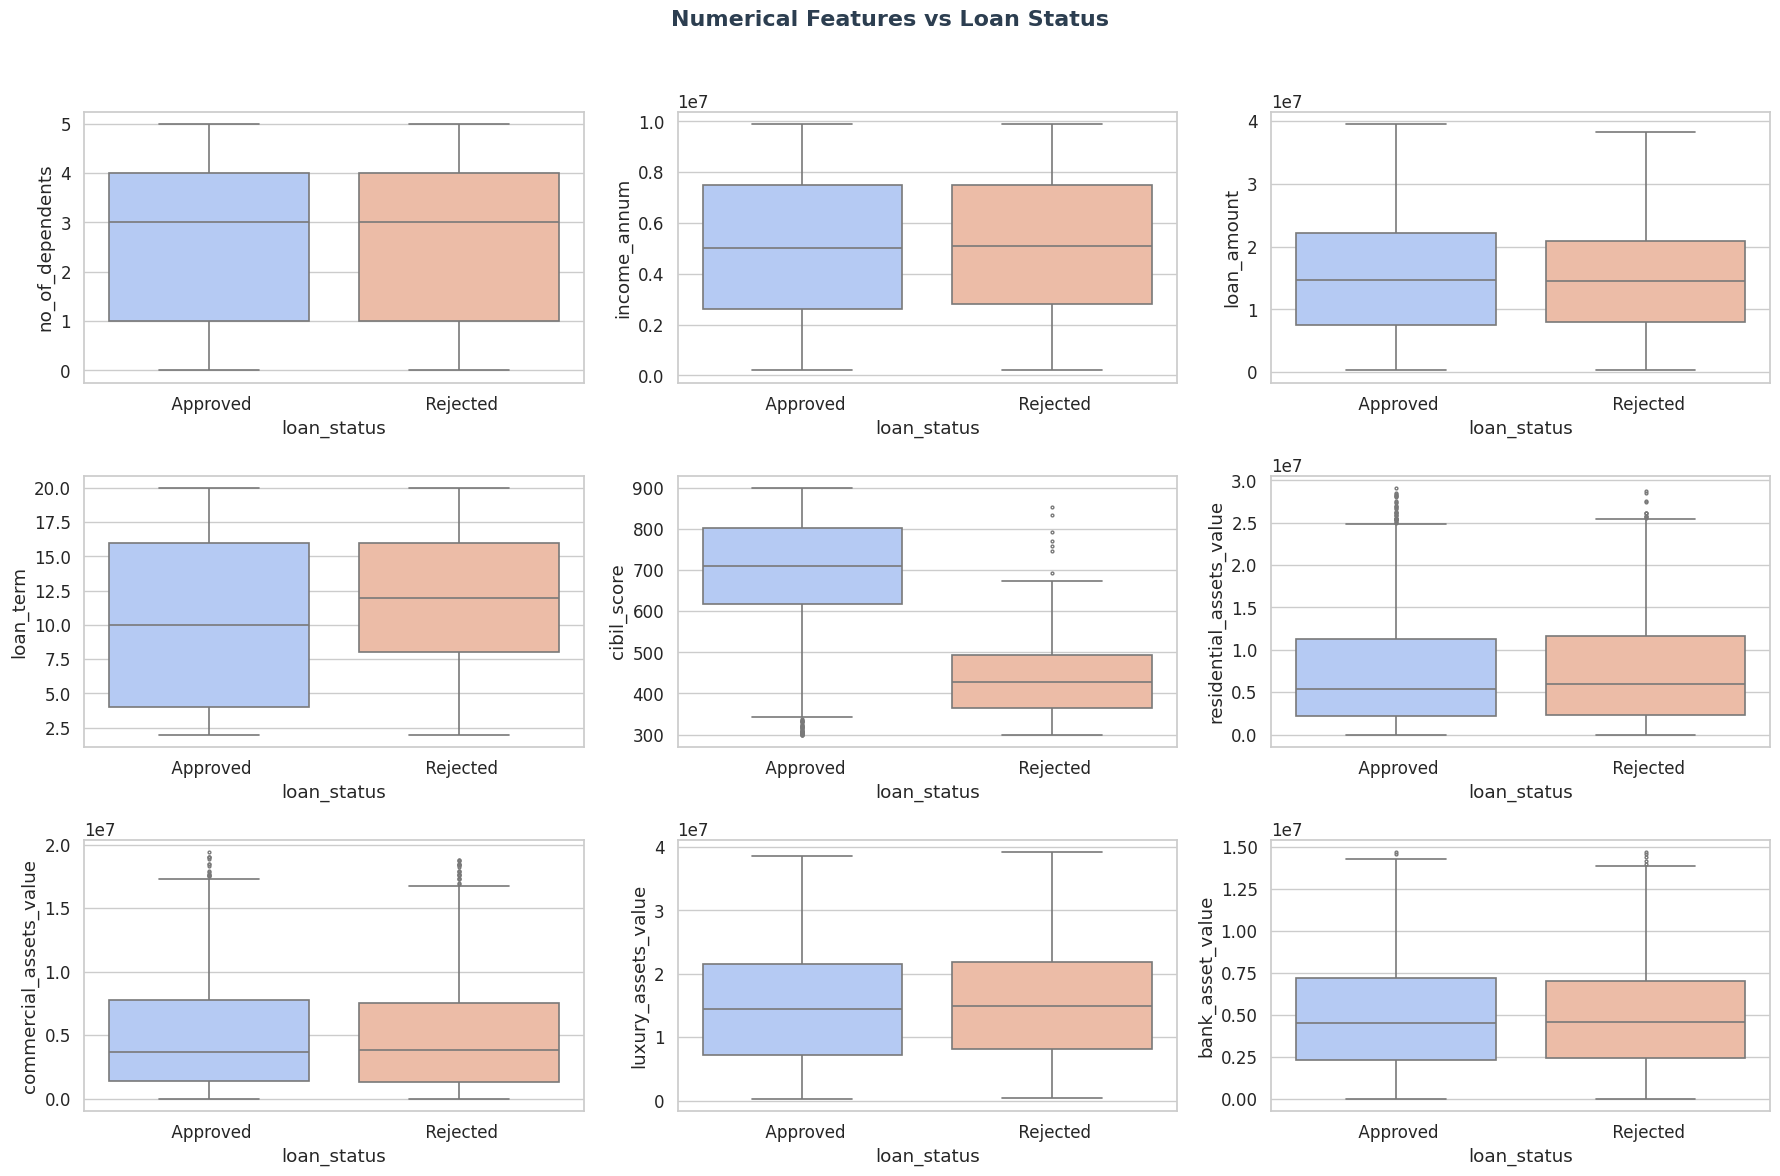

In [16]:
from matplotlib import axes
numeric_columns = [
    "no_of_dependents",
    "income_annum",
    "loan_amount",
    "loan_term",
    "cibil_score",
    "residential_assets_value",
    "commercial_assets_value",
    "luxury_assets_value",
    "bank_asset_value"
]

fig, axes = plt.subplots(nrows=3,
                         ncols=3,
                         figsize=(18, 12))

axes = axes.flatten()

for i, col in enumerate(numeric_columns):
    sns.boxplot(
        data=df,
        x=target,
        y=col,
        ax=axes[i],
        palette ="coolwarm",
        fliersize =2,
        linewidth=1.2
                )

plt.suptitle("Numerical Features vs Loan Status", fontsize=16, color="#2c3e50", fontweight="bold")
plt.tight_layout(rect =[0,0,1, 0.96])
plt.show()

# Coorelation Heatmap

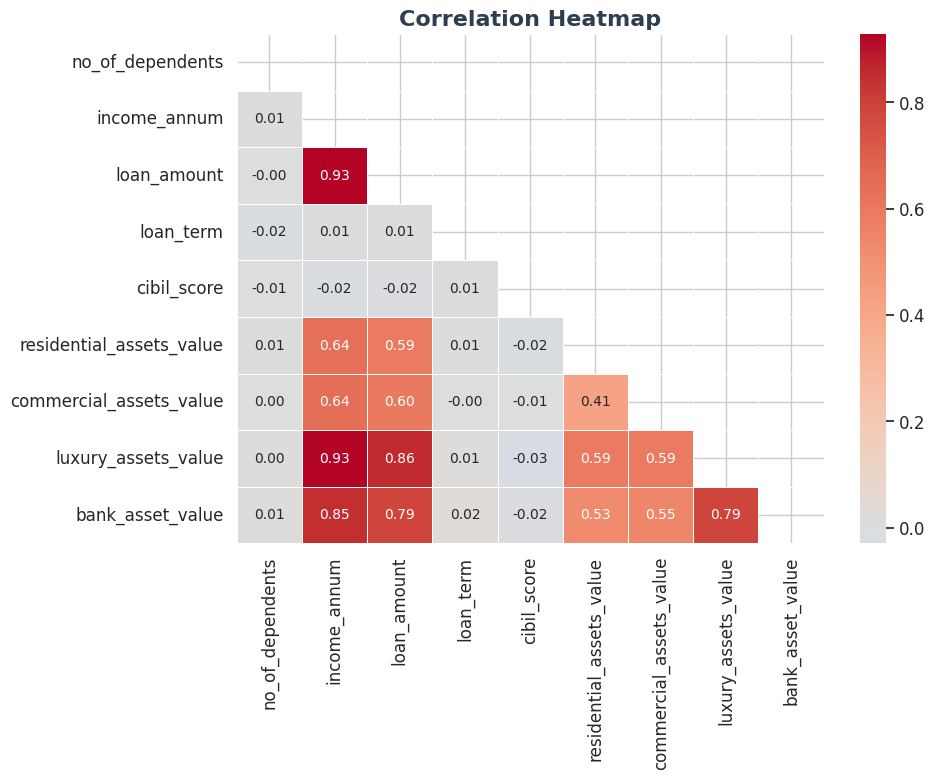

In [17]:
fig, ax = plt.subplots(figsize=(10, 8))

corr_matrix = df[numeric_columns].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap= "coolwarm", center=0, linewidths=0.5,
            linecolor ="white", ax=ax,
            annot_kws={"size": 10})

ax.set_title("Correlation Heatmap", fontsize=16, color="#2c3e50", fontweight="bold")
plt.tight_layout()
plt.show()


# Outlier Processing Before Splitting Data

In [18]:
from numpy._core.defchararray import lower
def remove_outliers(df, columns):
    Q1 = df[columns].quantile(0.25)
    Q3 = df[columns].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap the outliers instead of removing rows
    df_capped = df.copy()
    for col in columns:
        df_capped[col] = np.where(df_capped[col] < lower_bound[col], lower_bound[col], df_capped[col])
        df_capped[col] = np.where(df_capped[col] > upper_bound[col], upper_bound[col], df_capped[col])

    return df_capped

df = remove_outliers(df, numeric_columns)

print("Outliers capped successfully...")
print(f"New Data shape: {df.shape}")

Outliers capped successfully...
New Data shape: (4241, 12)


# Encoding Categorical Features

In [19]:
le = LabelEncoder()
df['education'] = le.fit_transform(df['education'])
df['self_employed'] = le.fit_transform(df['self_employed'])
df['loan_status'] = le.fit_transform(df['loan_status'])  # => target Variable

print("Categorical features encoded successfully...")
print(f"New Data shape: {df.shape}")
print(df.dtypes)

Categorical features encoded successfully...
New Data shape: (4241, 12)
no_of_dependents            float64
education                     int64
self_employed                 int64
income_annum                float64
loan_amount                 float64
loan_term                   float64
cibil_score                 float64
residential_assets_value    float64
commercial_assets_value     float64
luxury_assets_value         float64
bank_asset_value            float64
loan_status                   int64
dtype: object


In [20]:
for col in ['residential_assets_value', 'commercial_assets_value', 'bank_asset_value']:
    df[col] = df[col].astype('int64')

print("Converted float64 asset columns to int64 successfully...")
print(df.dtypes)

Converted float64 asset columns to int64 successfully...
no_of_dependents            float64
education                     int64
self_employed                 int64
income_annum                float64
loan_amount                 float64
loan_term                   float64
cibil_score                 float64
residential_assets_value      int64
commercial_assets_value       int64
luxury_assets_value         float64
bank_asset_value              int64
loan_status                   int64
dtype: object


# Splitting Features & Target Column

In [21]:
x = df.drop(columns=['loan_status'])
y = df['loan_status']

print(f"Features shape: {x.shape}")
print(f"Target shape: {y.shape}")

Features shape: (4241, 11)
Target shape: (4241,)


# Test_Train_split

In [22]:
x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

print(f"Training set: {x_train.shape}")
print(f"Test set: {x_test.shape}")

Training set: (3392, 11)
Test set: (849, 11)


In [23]:
# Feature Scaling
scaler = StandardScaler()

x_train_scale = scaler.fit_transform(x_train)
x_test_scale = scaler.transform(x_test)

print("Feature Scaling done successfully...")

Feature Scaling done successfully...


# Training Multiple Models

In [24]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=150, max_depth=8, random_state=42, n_jobs=-1)
}

results = {}

for name, model in models.items():
    model.fit(x_train_scale, y_train)
    y_pred = model.predict(x_test_scale)
    accuracy = accuracy_score(y_test, y_pred)
    cv = cross_val_score(model, x_train_scale, y_train,
                         cv=StratifiedKFold(n_splits=5),
                         scoring='accuracy')

    results[name] = {
        "model": model,
        "Accuracy": accuracy,
        "Cross Validation mean": cv.mean(),
        "CV std": cv.std(),
        "Target Prediction": y_pred
    }

    print(f"{name:<25}, Test: {accuracy: .4f}, CV : {cv.mean(): .4f} +/- {cv.std(): .4f}")

Logistic Regression      , Test:  0.9258, CV :  0.9142 +/-  0.0085
Decision Tree            , Test:  0.9694, CV :  0.9749 +/-  0.0032
Random Forest            , Test:  0.9764, CV :  0.9749 +/-  0.0037


# Best Model Selection

In [25]:
best_name = max(results, key=lambda n: results[n]["Cross Validation mean"])
best = results[best_name]
best_model = best["model"]

print(f"Best Model: {best_name}")
print(f"Accuracy: {best['Accuracy']}")
print(f"Cross Validation Mean: {best['Cross Validation mean']} +/- {best['CV std']}")

Best Model: Decision Tree
Accuracy: 0.9693757361601885
Cross Validation Mean: 0.9749427624347795 +/- 0.0032159612344535766


**Observations**

The Decision Tree model was selected as the best model based on its Cross Validation Mean score. Here's a breakdown of the model performances:

**Logistic Regression:**

* Test Accuracy: 0.9258
* Cross Validation Mean: 0.9142 +/- 0.0085


**Decision Tree:**

* Test Accuracy: 0.9694
* Cross Validation Mean: 0.9749 +/- 0.0032

**Random Forest:**

* Test Accuracy: 0.9764
* Cross Validation Mean: 0.9749 +/- 0.0037

As you can see, both the Decision Tree and Random Forest models achieved the highest Cross Validation Mean of 0.9749.

The selection logic in cell aujamUX10kEp (max(results, key=lambda n: results[n]["Cross Validation mean"])) picked the 'Decision Tree' in case of a tie for the maximum cross-validation mean.

While the Random Forest had a slightly higher test accuracy (0.9764 vs 0.9694), the primary criterion for 'best' was the cross-validation mean.

The Cross Validation Mean (0.9749) indicates how well the model generalizes to unseen data on average across multiple folds, suggesting strong and consistent performance. The relatively small CV Standard Deviation (0.0032) for the Decision Tree also shows that its performance was stable across different subsets of the training data.

# Saving the Best Model

In [44]:
# Saving the best model

import joblib
joblib.dump(best_model, "loan_approval_prediction_best_model.pkl")

print("Best model saved successfully...")

Best model saved successfully...


In [45]:
# Downloading the modal in a local file

from google.colab import files
files.download("loan_approval_prediction_best_model.pkl")

print("Best model downloaded successfully...")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Best model downloaded successfully...


# Classification report

In [26]:
print("=" * 55)
print(f" {' '*8} Classification Report -{best_name}")
print("=" * 55)
print(classification_report(y_test, best["Target Prediction"]))


          Classification Report -Decision Tree
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       528
           1       0.99      0.93      0.96       321

    accuracy                           0.97       849
   macro avg       0.97      0.96      0.97       849
weighted avg       0.97      0.97      0.97       849



# Confusion Matrix

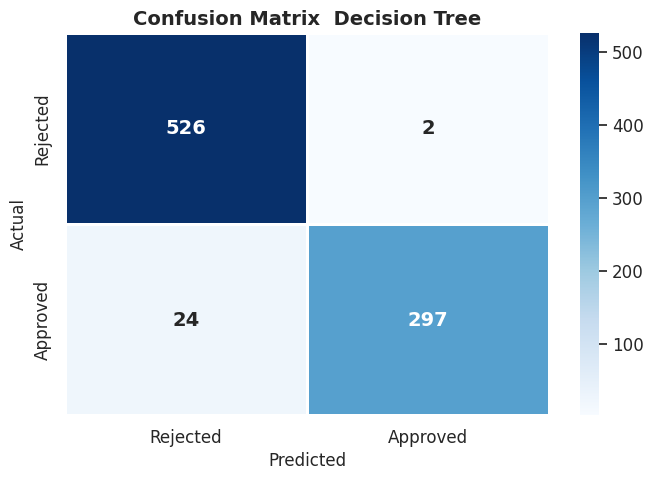

In [28]:
cm = confusion_matrix(y_test, best["Target Prediction"])

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Rejected", "Approved"],
            yticklabels=["Rejected", "Approved"],
            linewidths=1, linecolor="white",
            annot_kws={"size": 14, "weight": "bold"})
ax.set_title(f"Confusion Matrix  {best_name}", fontsize=14, fontweight="bold")
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("Actual", fontsize=12)
plt.tight_layout()
plt.show()

# ROC Curve

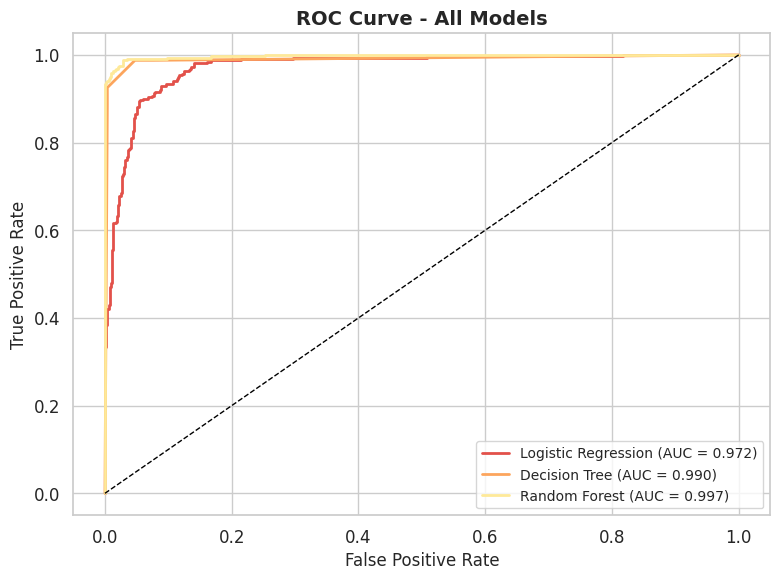

In [30]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, res in results.items():
    if hasattr(res["model"], "predict_proba"):
        y_prob = res["model"].predict_proba(x_test_scale)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc = roc_auc_score(y_test, y_prob)
        ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", linewidth=2)

ax.plot([0, 1], [0, 1], "k--", linewidth=1)
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curve - All Models", fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Overfitting Check

In [40]:
print("=" * 60)
print(f"{" "*18} OVERFITTING CHECK")
print("=" * 60)

for name, res in results.items():
    train_accuracy = accuracy_score(y_train, res["model"].predict(x_train_scale))
    test_accuracy  = res["Accuracy"]
    gap       = train_accuracy - test_accuracy
    status    = "OVERFIT" if gap > 0.05 else "OK"
    print(f"{name:<25} Train: {train_accuracy:.4f}  Test: {test_accuracy:.4f}  Gap: {gap:.4f}  [{status}]")

                   OVERFITTING CHECK
Logistic Regression       Train: 0.9180  Test: 0.9258  Gap: -0.0078  [OK]
Decision Tree             Train: 0.9791  Test: 0.9694  Gap: 0.0097  [OK]
Random Forest             Train: 0.9988  Test: 0.9764  Gap: 0.0224  [OK]


In [41]:
# sample applicants Data

sample_applicants = pd.DataFrame({
    "no_of_dependents"        : [0, 2, 4, 1, 3],
    "education"               : [1, 1, 0, 0, 1],
    "self_employed"           : [0, 0, 1, 0, 1],
    "income_annum"            : [9000000, 5500000, 2000000, 7500000, 3200000],
    "loan_amount"             : [5000000, 12000000, 20000000, 8000000, 15000000],
    "loan_term"               : [8, 12, 20, 6, 16],
    "cibil_score"             : [800, 650, 400, 750, 500],
    "residential_assets_value": [15000000, 8000000, 1000000, 12000000, 3000000],
    "commercial_assets_value" : [10000000, 4000000, 500000, 7000000, 1000000],
    "luxury_assets_value"     : [20000000, 9000000, 2000000, 14000000, 4000000],
    "bank_asset_value"        : [8000000, 3000000, 500000, 6000000, 1500000]
})

applicant_names = [
    "Applicant A - High Income",
    "Applicant B - Average Profile",
    "Applicant C - Low Income",
    "Applicant D - Good Credit",
    "Applicant E - High Risk"
]

print("Sample applicants created.")
sample_applicants

Sample applicants created.


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
0,0,1,0,9000000,5000000,8,800,15000000,10000000,20000000,8000000
1,2,1,0,5500000,12000000,12,650,8000000,4000000,9000000,3000000
2,4,0,1,2000000,20000000,20,400,1000000,500000,2000000,500000
3,1,0,0,7500000,8000000,6,750,12000000,7000000,14000000,6000000
4,3,1,1,3200000,15000000,16,500,3000000,1000000,4000000,1500000


In [43]:
# Loan approval prediction Results

sample_scaled   = scaler.transform(sample_applicants)
predictions     = best_model.predict(sample_scaled)
probabilities   = best_model.predict_proba(sample_scaled)

prob_approved   = [f"{p[1]*100:.1f}%" for p in probabilities]
prob_rejected   = [f"{p[0]*100:.1f}%" for p in probabilities]
decision        = ["APPROVED" if p == 1 else "REJECTED" for p in predictions]

results_df = pd.DataFrame({
    "Applicant"        : applicant_names,
    "Annual Income"    : [f"{v:,}" for v in sample_applicants["income_annum"]],
    "Loan Amount"      : [f"{v:,}" for v in sample_applicants["loan_amount"]],
    "CIBIL Score"      : sample_applicants["cibil_score"].values,
    "Loan Term (yrs)"  : sample_applicants["loan_term"].values,
    "Prob Approved"    : prob_approved,
    "Prob Rejected"    : prob_rejected,
    "Decision"         : decision
})

results_df.set_index("Applicant", inplace=True)
results_df

,Annual Income,Loan Amount,CIBIL Score,Loan Term (yrs),Prob Approved,Prob Rejected,Decision
Applicant,,,,,,,
Applicant A - High Income,"9,000,000","5,000,000",800,8,0.0%,100.0%,REJECTED
Applicant B - Average Profile,"5,500,000","12,000,000",650,12,0.0%,100.0%,REJECTED
Applicant C - Low Income,"2,000,000","20,000,000",400,20,100.0%,0.0%,APPROVED
Applicant D - Good Credit,"7,500,000","8,000,000",750,6,0.0%,100.0%,REJECTED
Applicant E - High Risk,"3,200,000","15,000,000",500,16,100.0%,0.0%,APPROVED


 ## Conclusion

 **Best Model:** Decision Tree Classifier *(selected based on the highest Cross-Validation Mean score and stable generalization performance)*

* **Accuracy:** **96.94%**

* **Precision:** **97%**

* **Recall:** **96%**

* **F1 Score:** **97%**

The **Decision Tree Classifier** demonstrated excellent performance by achieving a **96.94% test accuracy** along with **97% precision**, **96% recall**, and a **97% F1-score**. It was selected as the best model because it achieved the highest **cross-validation mean (97.49%)** with very low variation across folds, indicating strong and consistent generalization on unseen data.

Additionally, the overfitting analysis showed only a **small train-test performance gap (0.97%)**, confirming that the model is neither significantly overfitting nor underfitting.

Overall, the model is **accurate, reliable, and robust** for predicting loan approval decisions.

In [ ]:
# save the notebook in local file

from